# Imaging, part 2: regularised maximum likelihood

Part 1 simulated AMI data of a lopsided ring of dust next to a star. This part reconstructs the ring from those data, step by step, using **regularised maximum likelihood** (RML).

An image has far more pixels than an interferometer has independent measurements, so many images fit the data equally well. RML picks one by minimising

$$\mathcal{L}(\text{image}) = \tfrac{1}{2}\chi^2(\text{image}) + w\,R(\text{image}),$$

where χ² measures the misfit to the data and R is a **regulariser**: a penalty that prefers some images over others. This tutorial uses maximum entropy, which prefers smooth, positive images close to a flat default. The weight w sets the balance between the two terms. Too small a weight and the image fits the noise. Too large and it is smoothed into whatever the regulariser prefers.

The steps are:
1. look at the dirty image and the beam, to see what the data can resolve;
2. build a starting image, either from a parametric fit (moments) or from the dirty image;
3. fit once at a fixed weight;
4. sweep the weight with an L-curve, and choose it by the discrepancy principle;
5. check the result.

In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from drpangloss.coverage import ami_grid_record
from drpangloss.fitting import fit
from drpangloss.imaging import (
    MaxEntropy,
    beam,
    diagnose,
    dirty_image,
    field_of_view,
    image_priors,
    l_curve,
    nyquist_pixel_scale,
    starting_image,
)
from drpangloss.models import Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.scenes import ring

# The scene of part 1: a lopsided ring with 5% of the flux, next to a star.
template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
npix, pixel_scale = 64, 20.0
fov = npix * pixel_scale
truth_image = ring(npix, pixel_scale, radius_mas=240.0, width_mas=36.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.6, asymmetry_pa_deg=90.0)
truth = System(star=PointSource(), dust=Image.from_brightness(truth_image, pixel_scale, flux=0.05))
data = template.with_model(truth, key=jax.random.PRNGKey(1))

resolution = beam(data)
print(f"{data.vis.size} data (DISCO coefficients)")
print(f"beam {resolution.major_mas:.0f} × {resolution.minor_mas:.0f} mas; Nyquist pixel {nyquist_pixel_scale(data):.0f} mas; interferometric field of view {field_of_view(data, largest_mas=float('inf')):.0f} mas")

W1001 23:03:19.252200 11314505 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


588 data (DISCO coefficients)
beam 154 × 131 mas; Nyquist pixel 84 mas; interferometric field of view 3300 mas


## The dirty image and the beam

The simplest image is the **dirty image**, the inverse Fourier transform of the data with every unmeasured frequency set to zero. drpangloss's `dirty_image` computes it by least squares from the data's uv samples. Passing the star's flux ratio (`flux_ratio`) removes the star, so that only the extended emission is left.

The dirty image is the truth convolved with the **dirty beam**, the response to a point source. The beam's core sets the resolution. `beam(data)` approximates that core by an ellipse; its FWHM is shaded in the lower-left corner of every reconstructed image. The dirty image shows the ring, but it is not the answer: it is blurred by the beam, and its sidelobes add negative and spurious structure. Subtracting a star that is 20 times brighter than the ring also amplifies any small error in the data's normalisation. So `dirty_image` removes the star by subtracting the best-fitting point source rather than a fixed one.

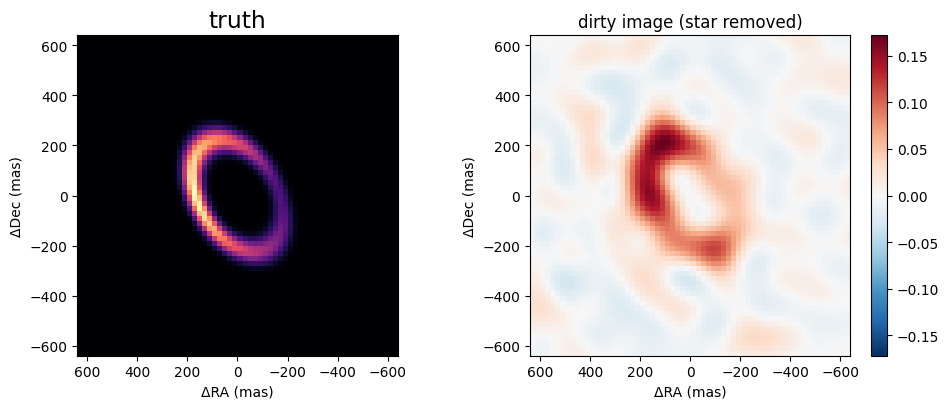

In [2]:
dirty = dirty_image(data, npix, pixel_scale, flux_ratio=0.05)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_model(truth.dust, fov_mas=fov, npix=npix, ax=axes[0], title="truth")
im = axes[1].imshow(dirty, origin="upper", extent=[fov / 2, -fov / 2, -fov / 2, fov / 2], cmap="RdBu_r", vmin=-abs(dirty).max(), vmax=abs(dirty).max())
axes[1].set(title="dirty image (star removed)", xlabel="ΔRA (mas)", ylabel="ΔDec (mas)")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## Starting images

The fit needs a starting image, and `starting_image` builds one from the data:
- **A parametric fit.** It fits a star plus a circular Gaussian envelope, and uses the envelope's flux and width.
- **A pixel grid.** The pixel scale is a quarter of the Nyquist pixel, and the field of view spans six envelope widths or 500 mas, whichever is larger, but no more than the interferometric field of view (here capped at the truth's field).
- **A hole under the star.** `hole_mas` cuts a hole of half a beam in the image's support there. Extended flux that close to the star is nearly indistinguishable from the star's own light, so without a hole the fit can trade one against the other.
- **The starting pixels.** `start="moments"` takes them from the fitted Gaussian. `start="dirty"` takes the positive part of the dirty image instead, which already has the right shape when the coverage is good, as it is here.

A star and an `Image` together make a `System`. The analytic star also fixes the image's position, which the closure phases alone cannot.

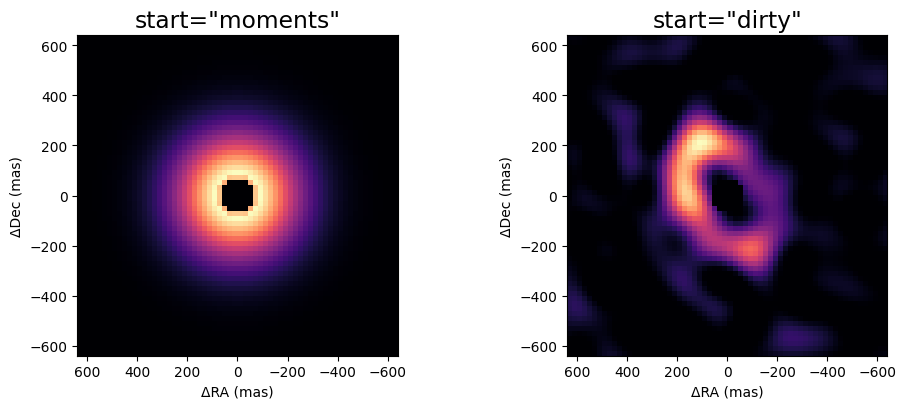

In [3]:
starts = {kind: starting_image(data, largest_mas=fov, start=kind, hole_mas=0.5 * resolution.minor_mas) for kind in ("moments", "dirty")}
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (kind, start) in zip(axes, starts.items()):
    plot_model(start.env, fov_mas=fov, npix=npix, ax=ax, title=f'start="{kind}"')
plt.tight_layout()
plt.show()

## One regularised fit

`fit` minimises the loss above:
- Its free parameters are the keys of the priors dict. `image_priors` gives flat priors on the image's log-brightness, so only the data and the regulariser constrain the pixels.
- The brightness is the softmax of the log-brightness, so it stays positive and sums to one. The image's flux is a separate parameter, and is fitted too.
- Maximum entropy has no least-squares form, so `fit` uses L-BFGS. It reports whether it converged, and runs in float64 by default.

Here is one fit, at w = 100.

In [4]:
start = starts["moments"]
priors = image_priors(start) | {"env.flux": dist.Uniform(0.0, 1.0)}
one = fit(start, priors, data, [MaxEntropy(100.0, path="env")])
print(f"converged {one.info['converged']} after {one.info['steps']} steps; chi2 per point {one.info['chi2_red']:.3f}; image flux {float(one.model.env.flux):.4f} (truth 0.05)")

converged True after 7211 steps; chi2 per point 0.989; image flux 0.0514 (truth 0.05)


## Choosing the weight: the L-curve and the discrepancy principle

`l_curve` fits the image at a sequence of weights, from strong to weak, each fit starting from the previous one. It records χ² and the unweighted penalty R of each fit. Two criteria read a weight off the sweep:
- **The discrepancy principle** (`LCurve.discrepancy`) chooses the weight at which χ² per data point reaches one. That is how well the truth itself fits noisy data, so it regularises as strongly as the data allow. It relies on correct error bars.
- **The corner** (`LCurve.corner`) is where the curve of log χ² against log R bends most sharply. It needs no error bars, but the corner of a coarse or noisy sweep is itself noisy.

Here both starting images are swept, and the two criteria are marked on each curve.

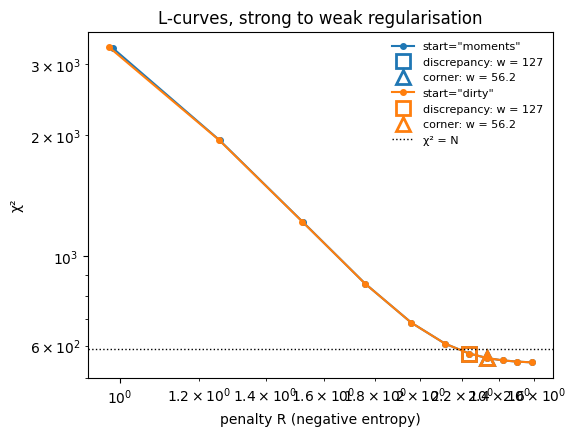

start="moments" converged at each weight: 3.16e+03: True, 1.78e+03: True, 1e+03: True, 562: True, 316: True, 178: True, 100: True, 56.2: True, 31.6: True, 17.8: True, 10: True
start="dirty" converged at each weight: 3.16e+03: True, 1.78e+03: True, 1e+03: True, 562: True, 316: True, 178: True, 100: True, 56.2: True, 31.6: True, 17.8: True, 10: True


In [5]:
weights = jnp.logspace(3.5, 1.0, 11)
curves = {kind: l_curve(s, image_priors(s) | {"env.flux": dist.Uniform(0.0, 1.0)}, data, MaxEntropy(1.0, path="env"), weights, max_steps=200_000) for kind, s in starts.items()}

fig, ax = plt.subplots(figsize=(6, 4.5))
for (kind, curve), colour in zip(curves.items(), ("C0", "C1")):
    ax.plot(curve.penalty, curve.chi2, "o-", color=colour, ms=4, label=f'start="{kind}"')
    for name, weight, marker in (("discrepancy", curve.discrepancy(), "s"), ("corner", curve.corner(), "^")):
        k = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))
        ax.plot(curve.penalty[k], curve.chi2[k], marker, color=colour, ms=10, mfc="none", mew=2, label=f"{name}: w = {weight:.3g}")
ax.axhline(data.vis.size, color="k", ls=":", lw=1, label="χ² = N")
ax.set(xscale="log", yscale="log", xlabel="penalty R (negative entropy)", ylabel="χ²", title="L-curves, strong to weak regularisation")
ax.legend(frameon=False, fontsize=8)
plt.show()
for kind, curve in curves.items():
    print(f'start="{kind}" converged at each weight: ' + ", ".join(f"{float(w):.3g}: {r.info['converged']}" for w, r in zip(curve.weights, curve.results)))

## Too much, about right, too little

A good weight sits in a range, not at a point. Here are three fits from the moments sweep: a decade more regularised than the discrepancy weight, at it, and a decade less. Too much regularisation blurs the ring into a smooth halo. Too little lets the image fit the noise, and it breaks into speckles.

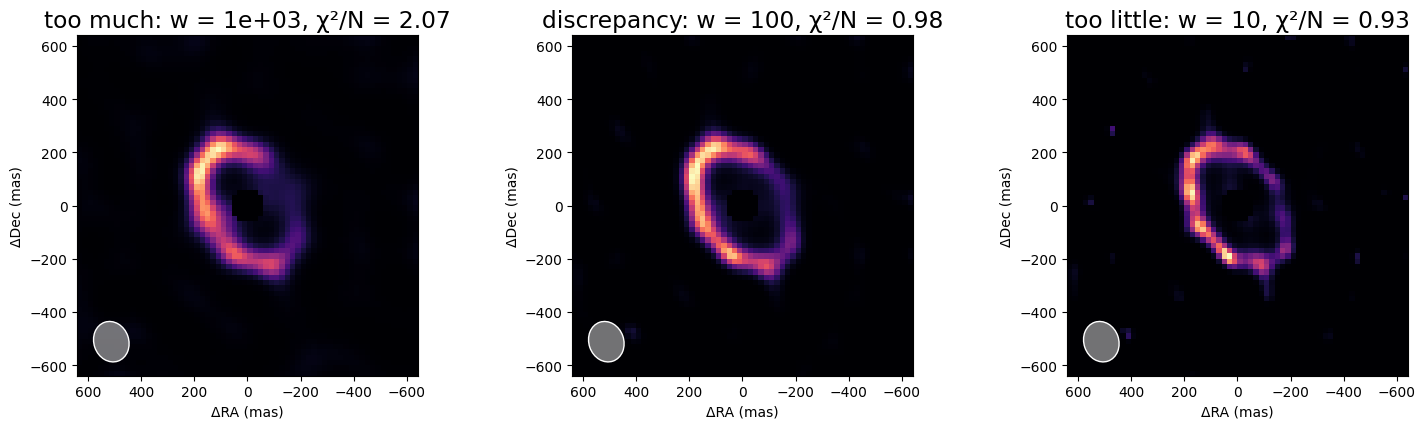

In [6]:
curve = curves["moments"]
chosen = curve.discrepancy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, factor, label in zip(axes, (10.0, 1.0, 0.1), ("too much", "discrepancy", "too little")):
    k = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(factor * chosen))))
    r = curve.results[k]
    plot_model(r.model.env, fov_mas=fov, npix=npix, ax=ax, title=f"{label}: w = {float(curve.weights[k]):.3g}, χ²/N = {r.info['chi2_red']:.2f}", beam=resolution)
plt.tight_layout()
plt.show()

## The result, and the two starting images

Each sweep's fit nearest its discrepancy weight is shown with the beam shaded, and below it the signed difference from the truth. These are maximum a posteriori images with no uncertainties, so the residuals are not z-scores. The two starting images converge to nearly the same reconstruction, which is a good sign that the fit has found the optimum rather than stopping near its start.

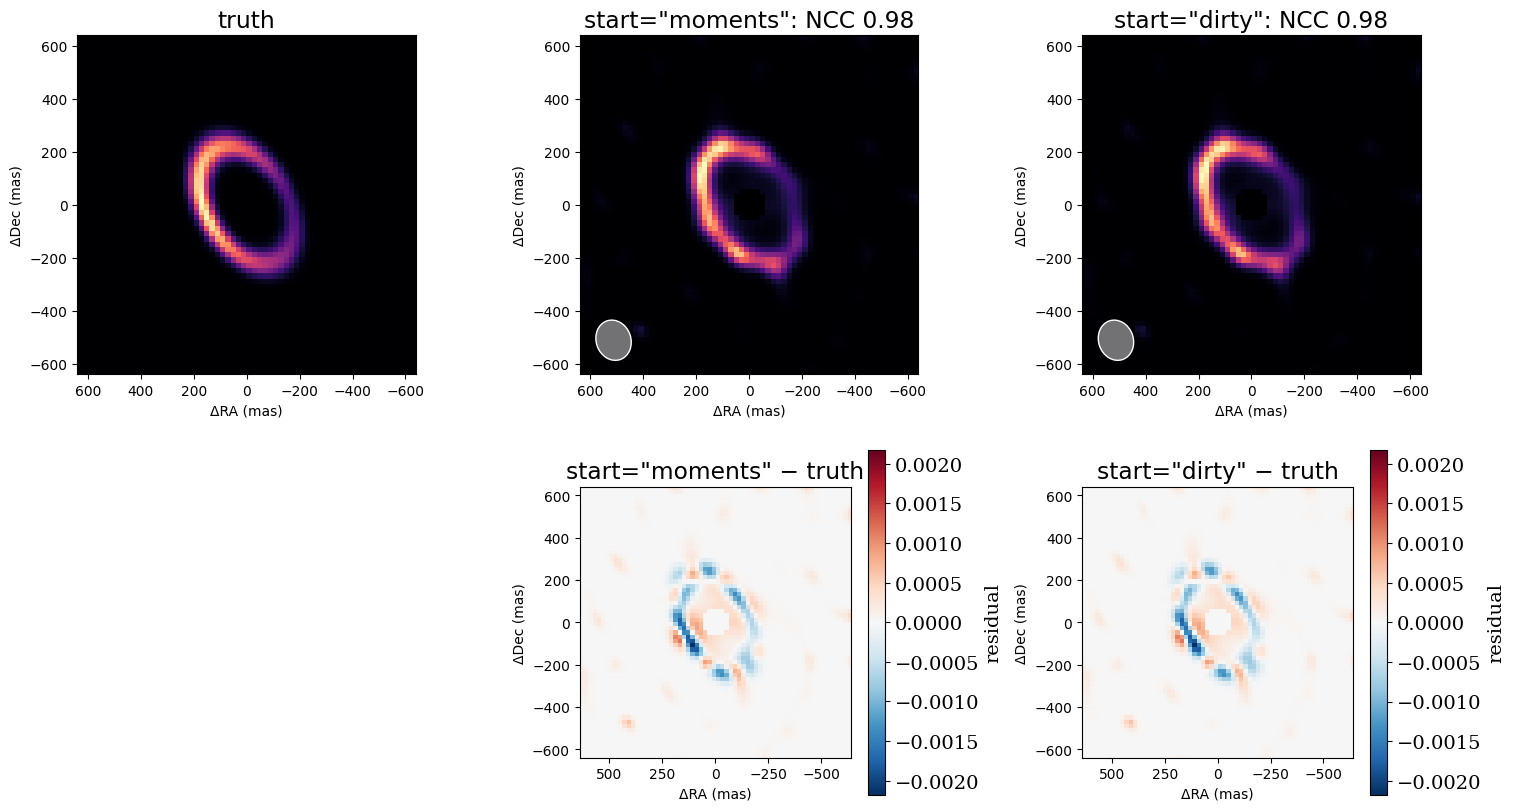

In [7]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
plot_model(truth.dust, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
final = {}
for column, (kind, curve) in enumerate(curves.items(), start=1):
    k = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(curve.discrepancy()))))
    final[kind] = curve.results[k].model
    image = final[kind].env.render(npix, fov)
    plot_model(final[kind].env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f'start="{kind}": NCC {ncc(image, truth_image):.2f}', beam=resolution)
    plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[1, column], title=f'start="{kind}" − truth')
plt.tight_layout()
plt.show()

## Checking the result

`diagnose` checks a reconstruction for common problems:
- χ² per point for each dataset;
- whether something anchors the image's position, here the star;
- the pixel scale against the Nyquist pixel;
- flux at the edge of the field, a sign that the field is too small;
- the image's centroid;
- how much worse χ² gets when the image is turned by 180°. A large value means the closure phases fix the orientation.

It warns when a check fails.

In [8]:
print(diagnose(final["moments"], data))

chi2_red         [0.977]
anchored         True
pixel_scale_mas  [20.9]
edge_flux        [0.0139]
centroid_mas     [[47.9, 18.9]]
flip_dchi2       2.04e+04
phase_regime     [0]

No warnings.


## Summary

RML turns the reconstruction into an optimisation of ½χ² + wR:
- **A starting image.** `starting_image` builds one from a parametric fit (moments) or from the dirty image, with a sensible grid and a hole under the star. With coverage this good, both starts lead to the same image.
- **The weight.** `l_curve` sweeps it with warm starts. The discrepancy principle chooses the weight at which χ² per point reaches one; the corner is a check that needs no error bars.
- **Checks.** Look at the images either side of the chosen weight, and run `diagnose`.

Part 3 replaces the maximum-entropy penalty with a Gaussian-process prior, whose two hyperparameters can be chosen from the Bayesian evidence instead of a sweep. `design/regulariser_weight_selection.md` discusses the criteria for choosing w in more depth.